---
# Partie 1 – Exploration du corpus

### 1) Charger les données CSV ;

In [44]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns

In [28]:
df = pd.read_csv('../data/smart_reviews_raw.csv')
df.head()

,id_avis,date,source,produit,texte,sentiment,note,langue
0,AV0001,2026-02-27,mobile,Ordinateur NovaBook,"Très bonne expérience, simple et efficace.",positif,4,fr
1,AV0002,2026-01-09,web,SmartPhone X,Très satisfait de mon achat 👍 #avis,positif,4,fr
2,AV0003,2026-07-03,réseaux_sociaux,Écouteurs AirSound,"Produit parfait, rien à signaler.",positif,4,fr
3,AV0004,2026-06-28,sav,SmartWatch Pro,"Produit excellent, je suis très satisfait. !!!",positif,5,fr
4,AV0005,2026-01-24,sav,SmartPhone X,LA BATTERIE TIENT VRAIMENT BIEN ET L'ÉCRAN EST...,positif,5,fr


### 2) Combien d'avis contient le dataset ?

In [29]:
f"il y a {df.shape[0]} avis"

'il y a 1200 avis'

### 3) Combien de colonnes possède-t-il ?

In [30]:
f"il y a {df.shape[1]} colonnes"

'il y a 8 colonnes'

### 4) Quel est le type de chaque colonne ?

In [31]:
df.dtypes

id_avis      object
date         object
source       object
produit      object
texte        object
sentiment    object
note          int64
langue       object
dtype: object

### 5) Existe-t-il des valeurs manquantes ?

In [32]:
df.isna().sum()

id_avis      0
date         0
source       0
produit      0
texte        5
sentiment    0
note         0
langue       0
dtype: int64

### 6) Identifier quelques types de texte en affichant par exemple : texte normal ; texte vide ; texte contenant une URL ; texte contenant une mention ; texte contenant un hashtag ; texte contenant des emojis ; texte avec beaucoup de ponctuation ; texte en majuscules ; texte avec répétition de caractères.

In [36]:
RE_URL = re.compile(r"https?://\S+")
RE_MENTION = re.compile(r"@\w+")
RE_HASHTAG = re.compile(r"#\w+")
RE_EMOJI = re.compile("[\U0001F300-\U0001FAFF\U00002600-\U000027BF]+", flags=re.UNICODE)
RE_PONCT_EXCESSIVE = re.compile(r"([!?.])\1{1,}")
RE_REPETITION_CARACTERE = re.compile(r"(.)\1{2,}")  # ex: "supeeeer", "!!!!"

texte = df["texte"].fillna("")

exemples = {
    "Texte normal": texte[(texte.str.len() > 20) & (texte.str.len() < 60)
                           & ~texte.str.contains(RE_URL) & ~texte.str.contains(RE_EMOJI)].iloc[0],
    "Texte vide": df.loc[df["texte"].isna() | (texte.str.strip() == ""), "texte"].head(1).tolist(),
    "Texte avec URL": texte[texte.str.contains(RE_URL)].iloc[0],
    "Texte avec mention": texte[texte.str.contains(RE_MENTION)].iloc[0],
    "Texte avec hashtag": texte[texte.str.contains(RE_HASHTAG)].iloc[0],
    "Texte avec emojis": texte[texte.str.contains(RE_EMOJI)].iloc[0],
    "Texte avec beaucoup de ponctuation": texte[texte.str.contains(RE_PONCT_EXCESSIVE)].iloc[0],
    "Texte en majuscules": texte[texte.str.isupper() & (texte.str.len() > 5)].iloc[0],
    "Texte avec répétition de caractères": texte[texte.str.contains(RE_REPETITION_CARACTERE)].iloc[0],
}

for label, exemple in exemples.items():
    print(f"--- {label} ---\n{exemple!r}\n")


--- Texte normal ---
'Très  bonne  expérience,  simple  et  efficace.'

--- Texte vide ---
[nan]

--- Texte avec URL ---
'Produit parfait, rien à signaler. https://example.com/commande/17'

--- Texte avec mention ---
'@client Livraison rapide et produit conforme à mes attentes.'

--- Texte avec hashtag ---
'Très satisfait de mon achat 👍 #avis'

--- Texte avec emojis ---
'Très satisfait de mon achat 👍 #avis'

--- Texte avec beaucoup de ponctuation ---
'Produit excellent, je suis très satisfait. !!!'

--- Texte en majuscules ---
"LA BATTERIE TIENT VRAIMENT BIEN ET L'ÉCRAN EST SUPERBE."

--- Texte avec répétition de caractères ---
'Produit excellent, je suis très satisfait. !!!'



C:\Users\papam\AppData\Local\Temp\ipykernel_6684\3837618499.py:18: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  "Texte avec beaucoup de ponctuation": texte[texte.str.contains(RE_PONCT_EXCESSIVE)].iloc[0],
C:\Users\papam\AppData\Local\Temp\ipykernel_6684\3837618499.py:20: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  "Texte avec répétition de caractères": texte[texte.str.contains(RE_REPETITION_CARACTERE)].iloc[0],


### 7) Mesurer la longueur des textes en créant une nouvelle colonne « longueur » pour déterminer : longueur minimale ; longueur maximale ; longueur moyenne ; médiane et quartiles.

In [38]:
df["longueur"] = df["texte"].fillna("").str.len()

print("Longueur minimale :", df["longueur"].min())
print("Longueur maximale :", df["longueur"].max())
print("Longueur moyenne  :", round(df["longueur"].mean(), 1))
print("Longueur médiane  :", df["longueur"].median())
print("Quartiles :")
print(df["longueur"].quantile([0.25, 0.5, 0.75]))


Longueur minimale : 0
Longueur maximale : 636
Longueur moyenne  : 49.0
Longueur médiane  : 48.0
Quartiles :
0.25    37.0
0.50    48.0
0.75    56.0
Name: longueur, dtype: float64


### 8) Visualiser la distribution de la longueur des avis puis répondre aux questions

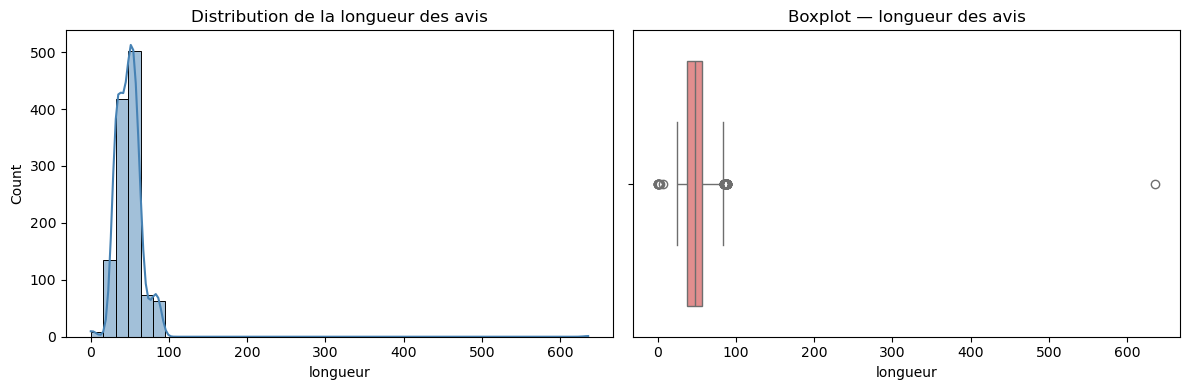

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["longueur"], bins=40, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Distribution de la longueur des avis")
sns.boxplot(x=df["longueur"], ax=axes[1], color="lightcoral")
axes[1].set_title("Boxplot — longueur des avis")
plt.tight_layout()
plt.show()

##### a) Existe-t-il des textes anormalement longs ?

In [46]:
q1, q3 = df["longueur"].quantile([0.25, 0.75])
iqr = q3 - q1
seuil_haut = q3 + 1.5 * iqr
textes_longs = df[df["longueur"] > seuil_haut]

print(f"a) {len(textes_longs)} avis anormalement longs (> {seuil_haut:.0f} caractères, borne IQR).")
print(textes_longs[["id_avis", "texte"]].head(3).to_string())

a) 41 avis anormalement longs (> 84 caractères, borne IQR).
    id_avis                                                                                     texte
31   AV0032    Je viens de recevoir le produit, à voir dans le temps. https://example.com/commande/32
51   AV0052    Je viens de recevoir le produit, à voir dans le temps. https://example.com/commande/52
110  AV0111  La batterie tient vraiment bien et l'écran est superbe. https://example.com/commande/111
